# Exploratory Data Analysis

In [1]:
import pandas as pd
from pathlib import Path
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import sys

sns.set_style("darkgrid")
pd.set_option("display.max_columns", 100)

ROOT = Path.cwd().parent.resolve()
DATASET_PATH = ROOT / "dataset" / "Airbnb_Data.csv"

df = pd.read_csv(DATASET_PATH)

df.head()

,id,log_price,property_type,room_type,amenities,accommodates,bathrooms,bed_type,cancellation_policy,cleaning_fee,city,description,first_review,host_has_profile_pic,host_identity_verified,host_response_rate,host_since,instant_bookable,last_review,latitude,longitude,name,neighbourhood,number_of_reviews,review_scores_rating,thumbnail_url,zipcode,bedrooms,beds
0,6901257,5.010635,Apartment,Entire home/apt,"{""Wireless Internet"",""Air conditioning"",Kitche...",3,1.0,Real Bed,strict,True,NYC,"Beautiful, sunlit brownstone 1-bedroom in the ...",2016-06-18,t,t,NaN,2012-03-26,f,2016-07-18,40.696524,-73.991617,Beautiful brownstone 1-bedroom,Brooklyn Heights,2,100.0,https://a0.muscache.com/im/pictures/6d7cbbf7-c...,11201,1.0,1.0
1,6304928,5.129899,Apartment,Entire home/apt,"{""Wireless Internet"",""Air conditioning"",Kitche...",7,1.0,Real Bed,strict,True,NYC,Enjoy travelling during your stay in Manhattan...,2017-08-05,t,f,100%,2017-06-19,t,2017-09-23,40.766115,-73.989040,Superb 3BR Apt Located Near Times Square,Hell's Kitchen,6,93.0,https://a0.muscache.com/im/pictures/348a55fe-4...,10019,3.0,3.0
2,7919400,4.976734,Apartment,Entire home/apt,"{TV,""Cable TV"",""Wireless Internet"",""Air condit...",5,1.0,Real Bed,moderate,True,NYC,The Oasis comes complete with a full backyard ...,2017-04-30,t,t,100%,2016-10-25,t,2017-09-14,40.808110,-73.943756,The Garden Oasis,Harlem,10,92.0,https://a0.muscache.com/im/pictures/6fae5362-9...,10027,1.0,3.0
3,13418779,6.620073,House,Entire home/apt,"{TV,""Cable TV"",Internet,""Wireless Internet"",Ki...",4,1.0,Real Bed,flexible,True,SF,This light-filled home-away-from-home is super...,NaN,t,t,NaN,2015-04-19,f,NaN,37.772004,-122.431619,Beautiful Flat in the Heart of SF!,Lower Haight,0,NaN,https://a0.muscache.com/im/pictures/72208dad-9...,94117.0,2.0,2.0
4,3808709,4.744932,Apartment,Entire home/apt,"{TV,Internet,""Wireless Internet"",""Air conditio...",2,1.0,Real Bed,moderate,True,DC,"Cool, cozy, and comfortable studio located in ...",2015-05-12,t,t,100%,2015-03-01,t,2017-01-22,38.925627,-77.034596,Great studio in midtown DC,Columbia Heights,4,40.0,NaN,20009,0.0,1.0


In [2]:
df.dtypes

id                          int64
log_price                 float64
property_type                 str
room_type                     str
amenities                     str
accommodates                int64
bathrooms                 float64
bed_type                      str
cancellation_policy           str
cleaning_fee                 bool
city                          str
description                   str
first_review                  str
host_has_profile_pic          str
host_identity_verified        str
host_response_rate            str
host_since                    str
instant_bookable              str
last_review                   str
latitude                  float64
longitude                 float64
name                          str
neighbourhood                 str
number_of_reviews           int64
review_scores_rating      float64
thumbnail_url                 str
zipcode                       str
bedrooms                  float64
beds                      float64
dtype: object

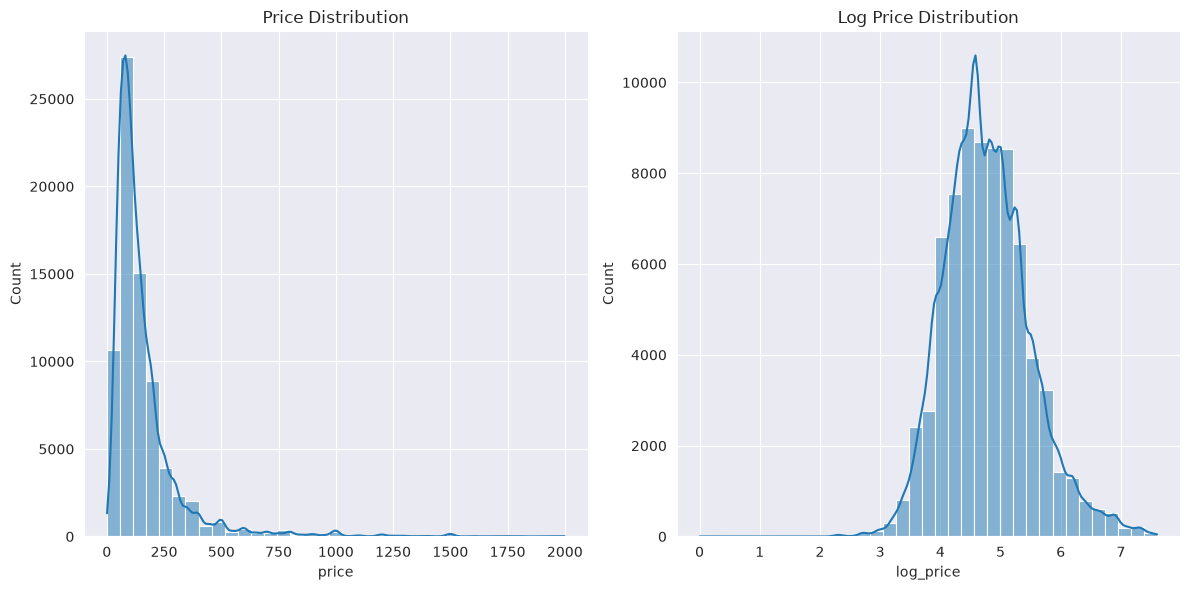

In [3]:
df['price'] = np.exp(df['log_price'])

fig, axes = plt.subplots(ncols=2, nrows=1, figsize=(12, 6))
sns.histplot(data=df, x='price', bins=35, kde=True, ax=axes[0])
sns.histplot(data=df, x='log_price', bins=35, kde=True, ax=axes[1])

axes[0].set_title("Price Distribution")
axes[1].set_title("Log Price Distribution")

plt.tight_layout()
plt.show()

## NaN Report

In [4]:
nan_report = df.isna().mean().sort_values(ascending=False)
nan_report

host_response_rate        0.246913
review_scores_rating      0.225635
first_review              0.214057
last_review               0.213558
thumbnail_url             0.110861
neighbourhood             0.092726
zipcode                   0.013035
bathrooms                 0.002699
host_identity_verified    0.002537
host_since                0.002537
host_has_profile_pic      0.002537
beds                      0.001768
bedrooms                  0.001228
property_type             0.000000
city                      0.000000
description               0.000000
cancellation_policy       0.000000
cleaning_fee              0.000000
bed_type                  0.000000
room_type                 0.000000
amenities                 0.000000
accommodates              0.000000
log_price                 0.000000
id                        0.000000
latitude                  0.000000
instant_bookable          0.000000
name                      0.000000
longitude                 0.000000
number_of_reviews   

In [5]:
(df['last_review'].isna() == df['first_review'].isna()).mean()

np.float64(0.9995007488766849)

In [6]:
(
    (df['host_identity_verified'].isna() == df['host_since'].isna()) &
    (df['host_identity_verified'].isna() == df['host_has_profile_pic'].isna())
).mean()

np.float64(1.0)

In [7]:
df['host_response_rate'] = pd.to_numeric(
    df['host_response_rate'].str.replace("%", "", regex=False),
    errors="coerce"
)

df['host_response_rate'].describe()

count    55812.000000
mean        94.351967
std         16.341817
min          0.000000
25%        100.000000
50%        100.000000
75%        100.000000
max        100.000000
Name: host_response_rate, dtype: float64

In [8]:
df['host_response_rate'].value_counts(normalize=True).head(10)

host_response_rate
100.0    0.774995
90.0     0.040798
80.0     0.019942
0.0      0.015821
50.0     0.010947
70.0     0.009102
99.0     0.008027
67.0     0.007758
98.0     0.007615
94.0     0.007185
Name: proportion, dtype: float64

In [9]:
(df['host_response_rate'].isna() == df['host_identity_verified'].isna()).mean()

np.float64(0.7556233217740956)

In [10]:
pd.crosstab(
    df['host_response_rate'].isna(),
    df['host_identity_verified'].isna()
)

host_identity_verified,False,True
host_response_rate,,
False,55812,0
True,18111,188


In [11]:
cols = nan_report[nan_report > 0].index.tolist()

for col in cols:
    print("\n-------------------------------------")
    print(df.groupby(df[col].isna())['price'].agg(
        ['count', 'mean', 'median']
    ))


-------------------------------------
                    count        mean  median
host_response_rate                           
False               55812  154.705726   110.0
True                18299  177.649489   115.0

-------------------------------------
                      count        mean  median
review_scores_rating                           
False                 57389  147.748297   110.0
True                  16722  203.690767   120.0

-------------------------------------
              count        mean  median
first_review                           
False         58247  147.794393   110.0
True          15864  206.547151   120.0

-------------------------------------
             count        mean  median
last_review                           
False        58284  147.785207   110.0
True         15827  206.718329   120.0

-------------------------------------
               count        mean  median
thumbnail_url                           
False          65895  153.18487

In [12]:
pd.crosstab(
    df['thumbnail_url'].isna(),
    df['first_review'].isna()
)

first_review,False,True
thumbnail_url,,
False,52325,13570
True,5922,2294


### Missing Value Analysis Conclusion

During the analysis of missing values, several features with missing values were identified. The highest proportion of missing values was found in:

* `host_response_rate` (~ 24.7%)
* `review_scores_rating` (~ 22.6%)
* `first_review` (~ 21.4%)
* `last_review` (~ 21.3%)
* `thumbnail_url` (~ 11.1%)
* `neighbourhood` (~ 9.3%)

The analysis showed that missing values in the dataset are **not random** and may represent meaningful information.

For *review-related* features (`first_review`, `last_review`), missing values show a strong relationship. In particular `first_review` and `last_review` have almost identical missingness patterns (~99%), suggesting that they represent the same factor: the presence and absence of review history.

Listings without review information have different price distributions compared to listings with reviews. Therefore, missing *review-related* values should not be removed as the absence of reviews itself may be an informative feature.

A similar pattern was observed for `host_response_rate`. The feature contains the largest proportion of missing values, while the available values are highly concentrated around 100%. Since missing values may indicate the absence of host interaction history rather than poor response performance, the missingness may carry predictive information.

The *host-related features* `host_has_profile_pic`, `host_identity_verified` and `host_since` were found to have identical missingness patterns across these features. This indicates that these missing values originate from the same issue. Creating one common flag, such as **host_missing** can be a possible solution.

The `thumbnail_url` feature also showed a meaningful relationship with price. Listings without thumbnail had a different price distribution, suggesting that the absence of an image may describe a specific group of listings rather than a random missing data.

Based on the analysis, the following preprocessing strategy will be considered for the modeling stage:

* Do not remove rows containing missing values, as many missing values appear to have specific predictive meaning.
* `host_response_rate` can be filled with median value, while preserving information through a binary indicator.
* Categorical features with missing values can be filled with **Unknown** value.
* *host-related features* may share one flag for missing values: **host_missing**. `host_since` is a **DateTime** feature and considered to transfrom DateTime information into host age(`days_count`) and fill missing values with median while preserving the missing flag.
* `thumbnail_url` is considered to be transformed into a binary feature.

----

## Duplicate Inspection

In [13]:
df_copy = df.drop(columns='id')

df_copy.duplicated().sum()

np.int64(0)

### Duplicate Inspection Conclusion

There are not duplicates in the dataset

## Target Variable Analysis

Goals for this section:

1. Understand price distribution
2. Identify skewness
3. Analyze asymmetry

In [14]:
df['price'].describe()

count    74111.000000
mean       160.370849
std        168.580415
min          1.000000
25%         75.000000
50%        111.000000
75%        185.000000
max       1999.000000
Name: price, dtype: float64

In [15]:
df[df['price'] == 1].T

,11632
id,17972519
log_price,0.0
property_type,Condominium
room_type,Shared room
amenities,"{TV,""Wireless Internet"",""Air conditioning"",Kit..."
accommodates,1
bathrooms,1.0
bed_type,Real Bed
cancellation_policy,strict
cleaning_fee,True


In [16]:
df[df['price'] <= 10]['city'].value_counts()

city
NYC    2
Name: count, dtype: int64

In [17]:
df[df['price'] <= 10]['room_type'].value_counts()

room_type
Entire home/apt    1
Shared room        1
Name: count, dtype: int64

In [18]:
df[df['price'] <= 6][[
    'price',
    'name',
    'room_type',
    'property_type',
    'accommodates',
    'bedrooms',
    'number_of_reviews',
    'review_scores_rating',
    'host_since'
]].T

,3898,11632
price,5.0,1.0
name,Upper West Side Studio Steps from Central Park,Esteem's Place
room_type,Entire home/apt,Shared room
property_type,Apartment,Condominium
accommodates,2,1
bedrooms,0.0,1.0
number_of_reviews,1,3
review_scores_rating,100.0,87.0
host_since,2013-08-14,2017-07-20


In [19]:
(df['log_price'] == 0).sum()

np.int64(1)

In [20]:
(df['log_price'] == 1).sum()

np.int64(0)

In [21]:
df['price'].nsmallest(20)

11632     1.0
3898      5.0
4466     10.0
6515     10.0
19806    10.0
21282    10.0
22268    10.0
23304    10.0
23917    10.0
25239    10.0
25655    10.0
26000    10.0
27021    10.0
28685    10.0
28693    10.0
37651    10.0
43269    10.0
48734    10.0
50577    10.0
52000    10.0
Name: price, dtype: float64

In [22]:
df.nsmallest(20, 'price')[[
    'city',
    'room_type',
    'property_type',
    'accommodates',
    'bedrooms',
    'number_of_reviews',
    'price'
]]

,city,room_type,property_type,accommodates,bedrooms,number_of_reviews,price
11632,NYC,Shared room,Condominium,1,1.0,3,1.0
3898,NYC,Entire home/apt,Apartment,2,0.0,1,5.0
4466,LA,Private room,Apartment,1,1.0,0,10.0
6515,Chicago,Private room,Apartment,1,1.0,78,10.0
19806,SF,Private room,Apartment,2,1.0,1,10.0
21282,Chicago,Shared room,House,2,1.0,1,10.0
22268,NYC,Private room,Apartment,2,1.0,0,10.0
23304,LA,Shared room,House,1,1.0,0,10.0
23917,NYC,Shared room,Apartment,1,1.0,2,10.0
25239,DC,Shared room,Apartment,4,1.0,41,10.0


In [23]:
df[df['price'] <= df['price'].quantile(0.01)][
    [
        'city',
        'room_type',
        'property_type',
        'accommodates',
        'bedrooms',
        'number_of_reviews',
        'price'
    ]
].sort_values('price')

,city,room_type,property_type,accommodates,bedrooms,number_of_reviews,price
11632,NYC,Shared room,Condominium,1,1.0,3,1.0
3898,NYC,Entire home/apt,Apartment,2,0.0,1,5.0
69004,SF,Entire home/apt,House,1,0.0,0,10.0
4466,LA,Private room,Apartment,1,1.0,0,10.0
57623,NYC,Private room,Apartment,1,0.0,2,10.0
...,...,...,...,...,...,...,...
4100,LA,Private room,Apartment,1,1.0,0,29.0
12056,NYC,Private room,Apartment,2,1.0,4,29.0
74030,LA,Shared room,Apartment,1,1.0,0,29.0
238,LA,Private room,House,1,1.0,4,29.0


In [24]:
df['price'].quantile([
    0.001,
    0.005,
    0.01,
    0.02,
    0.05,
    0.1
])

0.001    15.0
0.005    25.0
0.010    29.0
0.020    33.0
0.050    40.0
0.100    50.0
Name: price, dtype: float64

In [25]:
df['price'].quantile([
    0.90,
    0.95,
    0.99,
    0.995,
    0.999
])

0.900     300.0
0.950     425.0
0.990     986.8
0.995    1200.0
0.999    1650.0
Name: price, dtype: float64

In [26]:
    df['price'].skew(), df['log_price'].skew()

(np.float64(4.298408387699143), np.float64(0.5146954132526466))

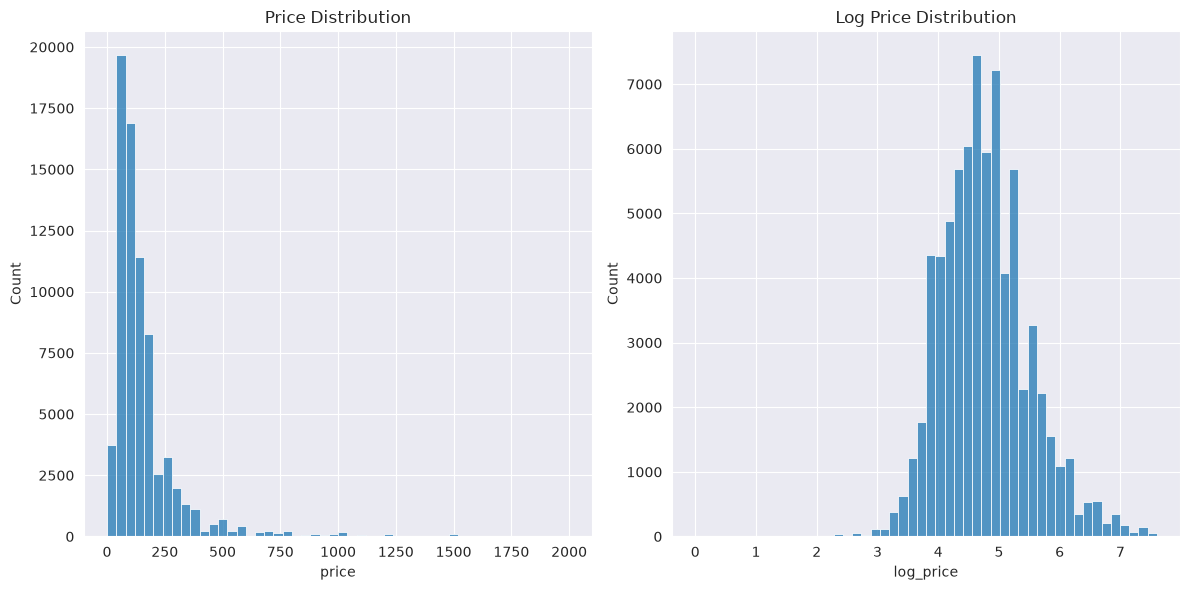

In [27]:
fig, axes = plt.subplots(ncols=2, nrows=1, figsize=(12, 6 ))

sns.histplot(data=df, x='price', bins=50, ax=axes[0])
sns.histplot(data=df, x='log_price', bins=50, ax=axes[1])

axes[0].set_title("Price Distribution")
axes[1].set_title("Log Price Distribution")

plt.tight_layout()
plt.show()

### Target Variable Analysis Conclusion

The target varibale `price` shows a strong right-skewed distribution with a skewness value of 4.30.

Most listings are connected in the lower price range, while a small number of expensive listings create a long right tail.

The analysis of quantiles shows that 90% of listings have a price below `$300`, while the top 1% of listings exceed approximately `$987`. These high-priced observations represent a small premium segment rather than obvious data errors.

The lower tail was also investigated. A single listing with a price of `$1` was identified. After examining its associated features, the observation appeared to be a valid but extremely low-priced listings. Since no clear data inconsistencies were found, these observations were retained.

The logarithmic transformation (`log_price`) significantly reduces the skewness from 4.30 to 0.51, resulting in a more balanced target distribution. Therefore, `log_price` will be used as a target variable for regression modeling.

## DateTime Analysis

In [28]:
date_cols = [
    'first_review',
    'host_since',
    'last_review'
]

for col in date_cols:
    df[col] = pd.to_datetime(df[col])

df[date_cols].dtypes

first_review    datetime64[us]
host_since      datetime64[us]
last_review     datetime64[us]
dtype: object

In [29]:
df[date_cols].describe()

,first_review,host_since,last_review
count,58247,73923,58284
mean,2016-01-14 08:11:51.013443,2014-07-21 01:55:09.849438,2017-03-14 19:27:18.789376
min,2008-11-17 00:00:00,2008-03-03 00:00:00,2009-01-21 00:00:00
25%,2015-06-28 00:00:00,2013-04-21 00:00:00,2017-01-09 00:00:00
50%,2016-05-25 00:00:00,2014-09-28 00:00:00,2017-04-28 00:00:00
75%,2017-01-02 00:00:00,2015-12-22 00:00:00,2017-09-08 00:00:00
max,2017-10-05 00:00:00,2017-10-04 00:00:00,2017-10-05 00:00:00


In [30]:
reference_date = df['host_since'].max()

df['host_age_days'] = (reference_date - df['host_since']).dt.days
df['host_age_days'].describe()

count    73923.000000
mean      1170.920025
std        661.497132
min          0.000000
25%        652.000000
50%       1102.000000
75%       1627.000000
max       3502.000000
Name: host_age_days, dtype: float64

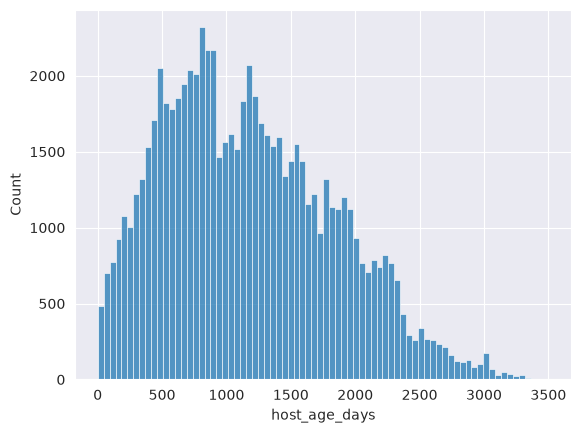

In [31]:
sns.histplot(data=df, x='host_age_days')
plt.show()

In [32]:
reference_date = df['last_review'].max()

df['days_since_last_review'] = (
    reference_date - df['last_review']
).dt.days

df['days_since_last_review'].describe()

count    58284.000000
mean       204.189366
std        231.729791
min          0.000000
25%         27.000000
50%        160.000000
75%        269.000000
max       3179.000000
Name: days_since_last_review, dtype: float64

In [33]:
df['review_history_days'] = (
    df['last_review'] - df['first_review']
).dt.days

df['review_history_days'].describe()

count    58247.000000
mean       425.461311
std        488.988636
min          0.000000
25%         52.000000
50%        264.000000
75%        623.000000
max       3106.000000
Name: review_history_days, dtype: float64

In [34]:
df['host_since_year'] = df['host_since'].dt.year
df['last_review_year'] = df['last_review'].dt.year
df['first_review_year'] = df['first_review'].dt.year

In [35]:
df[df['first_review'] < df['host_since']][[
    'host_since',
    'first_review',
    'last_review',
    'review_scores_rating',
    'price'
]]

,host_since,first_review,last_review,review_scores_rating,price
163,2013-09-25,2013-08-01,2017-09-20,88.0,90.0
950,2013-12-13,2012-05-21,2017-09-09,91.0,75.0
3828,2012-02-05,2011-12-24,2017-03-22,98.0,58.0
5401,2012-08-27,2012-07-23,2017-04-30,88.0,109.0
6736,2013-07-25,2012-10-27,2017-03-05,93.0,100.0
7634,2012-03-04,2011-07-11,2017-09-19,93.0,480.0
8097,2015-10-15,2015-07-06,2017-04-27,96.0,180.0
8888,2013-11-20,2013-05-06,2016-12-25,95.0,450.0
11237,2013-11-20,2012-04-01,2017-04-03,100.0,190.0
12765,2013-10-06,2013-05-06,2016-09-14,93.0,90.0


In [36]:
(df['first_review'] < df['host_since']).sum()

np.int64(44)

In [37]:
df['review_before_host'] = (
    df['first_review'] < df['host_since']
).astype(int)

In [38]:
datetime_features = [
    'host_age_days',
    'days_since_last_review',
    'review_history_days',
    'review_before_host'
]

df[datetime_features + ['log_price']].corr()['log_price'].sort_values()

review_before_host        0.007554
days_since_last_review    0.021550
review_history_days       0.073443
host_age_days             0.078333
log_price                 1.000000
Name: log_price, dtype: float64

In [39]:
df.groupby('host_since_year')['price'].agg(
    ['median', 'mean', 'count']
)

,median,mean,count
host_since_year,,,
2008.0,95.0,137.439560,91
2009.0,129.0,162.646132,698
2010.0,125.0,157.367497,1766
2011.0,125.0,170.343769,4887
2012.0,120.0,163.315359,8308
2013.0,120.0,162.920775,10729
2014.0,114.0,161.452009,13690
2015.0,108.0,157.326087,15594
2016.0,100.0,159.080667,13190


In [40]:
df.groupby('first_review_year')['price'].agg(
    ['median', 'mean', 'count']
)

,median,mean,count
first_review_year,,,
2008.0,36.0,36.000000,1
2009.0,120.0,129.160714,56
2010.0,124.5,140.388889,252
2011.0,125.0,152.956835,695
2012.0,125.0,164.444444,1503
2013.0,125.0,163.519231,2704
2014.0,120.0,158.356285,5243
2015.0,115.0,151.024842,12036
2016.0,109.0,145.647866,20779


In [41]:
df.groupby('first_review_year')['number_of_reviews'].median()

first_review_year
2008.0    31.0
2009.0    75.0
2010.0    68.5
2011.0    57.0
2012.0    42.0
2013.0    40.0
2014.0    28.0
2015.0    16.0
2016.0    10.0
2017.0     4.0
Name: number_of_reviews, dtype: float64

### DataTime Analysis Conclusion

The datetime features `host_since`, `first_review` and `last_review` were converted from string format and analyzed to identify potential temporal patterns related to the target variable.

The analysis showed that `host_since` represents the registration date of the host rather than the creation date of the listing. Therefore, direct comparison between host-related and listing-related dates should be interpreted carefully.

During the analysis, a small number of listings were identified where the first review date was earlier than the host registration date. Although this pattern may initially appear to indicate inccorect data, further investigation showed that these observations contained valid listing information and realistic feature values. Such cares may occur due to platform history, listing transfers, or changes related to host accounts. Since these observations represented only a very small fraction of the dataset and no clear inconsistencies were found, they are retained.

Several temporal patterns were identified. Older hosts and listings with longer review history showed slightly higher median prices, although the relationships were weak. This suggests that temporal information may provide additional predictive value, but it is unlikely to be one of the strongest prices drivers compared to structural and location-based features.

The following datetime-based features are reccomended for creation during preprocessing stage:

* `host_age_days` - number of days since the host joined the platform;
* `review_history_days` - duration between the first and last review;
* `days_since_last_review` - recency of the latest review activity;
* `first_review_year` - year when the listing received its first review;
* `host_since_year` - year when the host joined the platform;
* `has_reviews` - binary indicator showing whether the listing has review history;
* `review_before_host` - binary indicator for rare cases where the first review date is earlier than the host registration date;

Overall, datetime features will be included as additional model inputs, while expecting their contribution to be smaller compared to features describing property charasteristics, location and capacity.

## Numerical Feature Analysis

In [42]:
num_cols = [
    'accommodates',
    'bathrooms',
    'host_response_rate',
    'number_of_reviews',
    'review_scores_rating',
    'bedrooms',
    'beds'
]

In [43]:
df['accommodates'].describe()

count    74111.000000
mean         3.155146
std          2.153589
min          1.000000
25%          2.000000
50%          2.000000
75%          4.000000
max         16.000000
Name: accommodates, dtype: float64

In [44]:
df.groupby('accommodates')['price'].agg([
    'mean', 'median', 'count'
])

,mean,median,count
accommodates,,,
1,80.317787,64.0,9434
2,112.118039,90.0,31854
3,143.534514,124.0,7794
4,190.128957,150.0,12066
5,234.147793,186.5,3444
6,291.572147,225.0,4969
7,311.524313,250.0,946
8,394.129805,300.0,1795
9,359.777778,299.0,270


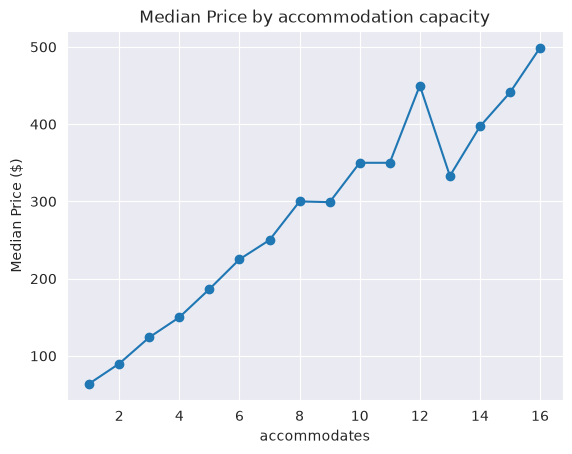

In [45]:
df.groupby('accommodates')['price'].median().plot(marker='o')
plt.title("Median Price by accommodation capacity")
plt.ylabel("Median Price ($)")
plt.show()

In [46]:
df.groupby(['bedrooms', 'room_type'])['price'].agg([
    'median', 'mean', 'count'
])

median        mean  count
bedrooms room_type                                 
0.0      Entire home/apt   125.0  146.456079   6284
         Private room       79.0  108.236659    431
1.0      Entire home/apt   140.0  165.574127  18320
         Private room       74.0   86.860585  29301
         Shared room        45.0   63.681923   2163
2.0      Entire home/apt   199.0  239.885658  10696
         Private room       95.0  131.015267    655
3.0      Entire home/apt   289.0  358.076979   4144
         Private room       75.0  131.866667    165
4.0      Entire home/apt   400.0  512.552776   1279
         Private room       65.0  169.333333     51
5.0      Entire home/apt   500.0  649.646199    342
         Private room       50.0   91.307692     13
6.0      Entire home/apt   750.0  810.504762    105
         Private room       60.0   60.000000      1
7.0      Entire home/apt   720.0  870.710526     38
8.0      Entire home/apt   700.0  916.615385     13
         Private room       30.0   30.000000      1
9.0      Entire home/apt   714.5  807.375000      8
10.0     Entire home/apt   697.5  824.000000     10

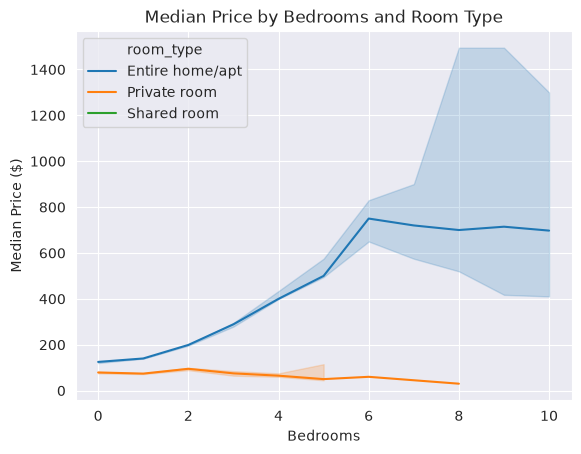

In [47]:
sns.lineplot(
    data=df,
    x='bedrooms',
    y='price',
    hue='room_type',
    estimator='median'
)

plt.title("Median Price by Bedrooms and Room Type")
plt.xlabel("Bedrooms")
plt.ylabel("Median Price ($)")
plt.show()

In [48]:
df.groupby('beds')['price'].agg([
    'median', 'mean', 'count'
])

,median,mean,count
beds,,,
0.0,247.0,250.750000,4
1.0,90.0,112.666600,45144
2.0,149.0,182.960967,16704
3.0,199.0,258.031046,6442
4.0,249.0,319.576509,3065
5.0,299.0,393.002331,1287
6.0,300.0,410.907716,661
7.0,364.0,457.805556,216
8.0,299.0,371.790323,186


In [49]:
df[df['beds'] == 0][[
    'price', 'room_type', 'bed_type', 'accommodates', 'beds', 'bedrooms'
]]

,price,room_type,bed_type,accommodates,beds,bedrooms
13672,169.0,Entire home/apt,Real Bed,2,0.0,1.0
24062,325.0,Entire home/apt,Real Bed,2,0.0,0.0
39057,109.0,Entire home/apt,Real Bed,2,0.0,0.0
55285,400.0,Entire home/apt,Real Bed,4,0.0,1.0


In [50]:
(df['beds'] > df['accommodates']).sum()

np.int64(507)

In [51]:
df[df['beds'] > df['accommodates']][[
    'price', 'accommodates', 'beds', 'bedrooms', 'bed_type', 'room_type'
]].head(20)

,price,accommodates,beds,bedrooms,bed_type,room_type
279,185.0,2,5.0,1.0,Real Bed,Private room
400,85.0,4,5.0,3.0,Real Bed,Entire home/apt
690,75.0,1,2.0,0.0,Real Bed,Private room
696,50.0,1,3.0,1.0,Real Bed,Shared room
932,150.0,1,2.0,2.0,Real Bed,Private room
1052,50.0,1,16.0,1.0,Real Bed,Shared room
1453,300.0,4,13.0,5.0,Real Bed,Private room
1519,250.0,3,4.0,3.0,Real Bed,Entire home/apt
1577,180.0,6,7.0,2.0,Real Bed,Entire home/apt
1789,300.0,1,2.0,1.0,Real Bed,Private room


In [52]:
df.groupby('bathrooms')['price'].agg([
    'median', 'mean', 'count'
])

,median,mean,count
bathrooms,,,
0.0,65.0,98.742424,198
0.5,65.0,92.344498,209
1.0,100.0,131.074941,58099
1.5,100.0,165.174428,3801
2.0,199.0,246.957283,7936
2.5,275.0,356.013401,1567
3.0,325.0,380.442777,1066
3.5,495.0,560.379953,429
4.0,450.0,508.881119,286


In [53]:
(df['bathrooms'] == 0).sum()

np.int64(198)

In [54]:
df[df['bathrooms'] == 0][[
    'price', 'room_type', 'bedrooms', 'bathrooms', 'property_type'
]].head(20)

,price,room_type,bedrooms,bathrooms,property_type
318,35.0,Private room,1.0,0.0,Apartment
1356,50.0,Shared room,1.0,0.0,Bed & Breakfast
1441,70.0,Private room,1.0,0.0,Apartment
1704,40.0,Private room,1.0,0.0,House
1819,90.0,Private room,1.0,0.0,Apartment
2034,35.0,Private room,1.0,0.0,Dorm
2068,36.0,Private room,1.0,0.0,House
2298,43.0,Private room,1.0,0.0,Condominium
2356,130.0,Private room,1.0,0.0,Apartment
2582,140.0,Entire home/apt,0.0,0.0,Apartment


In [55]:
df[df['bathrooms'] == 8].groupby('bedrooms')['price'].agg([
    'median', 'mean', 'count'
])

,median,mean,count
bedrooms,,,
0.0,70.0,70.000000,2
1.0,35.0,45.344828,29
5.0,1500.0,1500.000000,1
6.0,1700.0,1633.333333,3
7.0,1850.0,1876.666667,3
10.0,950.0,1183.333333,3


In [56]:
df[
    (df['bathrooms'] == 8) &
    (df['bedrooms'] == 1)
][
    ['price', 'accommodates', 'room_type', 'property_type', 'beds']
]

,price,accommodates,room_type,property_type,beds
6076,30.0,2,Shared room,House,2.0
8140,27.0,4,Shared room,Other,4.0
8290,54.0,1,Shared room,Dorm,1.0
8384,54.0,1,Shared room,Dorm,1.0
11109,33.0,1,Shared room,Dorm,4.0
11140,54.0,1,Shared room,Dorm,1.0
13253,100.0,2,Private room,Apartment,1.0
13370,35.0,1,Shared room,Hostel,1.0
14076,46.0,6,Shared room,Dorm,6.0
16352,44.0,4,Shared room,Hostel,1.0


In [57]:
num_cols

['accommodates',
 'bathrooms',
 'host_response_rate',
 'number_of_reviews',
 'review_scores_rating',
 'bedrooms',
 'beds']

In [58]:
df['host_response_rate'].describe()

count    55812.000000
mean        94.351967
std         16.341817
min          0.000000
25%        100.000000
50%        100.000000
75%        100.000000
max        100.000000
Name: host_response_rate, dtype: float64

In [59]:
df['host_response_rate'].value_counts().head(20)

host_response_rate
100.0    43254
90.0      2277
80.0      1113
0.0        883
50.0       611
70.0       508
99.0       448
67.0       433
98.0       425
94.0       401
97.0       400
96.0       350
60.0       337
95.0       322
88.0       316
92.0       315
75.0       315
89.0       310
93.0       307
83.0       279
Name: count, dtype: int64

In [60]:
df['response_group'] = pd.cut(
    df['host_response_rate'],
    bins=[0, 1, 50, 80, 95, 100]
)

df.groupby('response_group')['price'] \
    .agg(['median', 'mean', 'count']) \
    .sort_index()

,median,mean,count
response_group,,,
"(1, 50]",100.0,157.044463,1192
"(50, 80]",115.0,163.363584,3482
"(80, 95]",110.0,160.914652,5378
"(95, 100]",110.0,152.820755,44877


In [61]:
df.groupby(['response_group', 'room_type'])['price'].agg([
    'median', 'mean', 'count'
])

median        mean  count
response_group room_type                                 
(1, 50]        Entire home/apt   165.0  229.505843    599
               Private room       75.0   87.199248    532
               Shared room        50.0   54.639344     61
(50, 80]       Entire home/apt   170.0  223.075162   2009
               Private room       73.0   83.769231   1352
               Shared room        42.0   61.305785    121
(80, 95]       Entire home/apt   170.0  225.345872   3004
               Private room       70.0   81.944470   2179
               Shared room        43.0   50.784615    195
(95, 100]      Entire home/apt   159.0  207.107630  25532
               Private room       71.0   83.204158  18133
               Shared room        40.0   50.762376   1212

In [62]:
df.groupby('response_group')['number_of_reviews'].agg([
    'median', 'mean', 'count'
])

,median,mean,count
response_group,,,
"(1, 50]",2.0,8.130034,1192
"(50, 80]",5.0,14.669443,3482
"(80, 95]",10.0,24.353663,5378
"(95, 100]",12.0,28.632128,44877


In [63]:
df['number_of_reviews'].describe()

count    74111.000000
mean        20.900568
std         37.828641
min          0.000000
25%          1.000000
50%          6.000000
75%         23.000000
max        605.000000
Name: number_of_reviews, dtype: float64

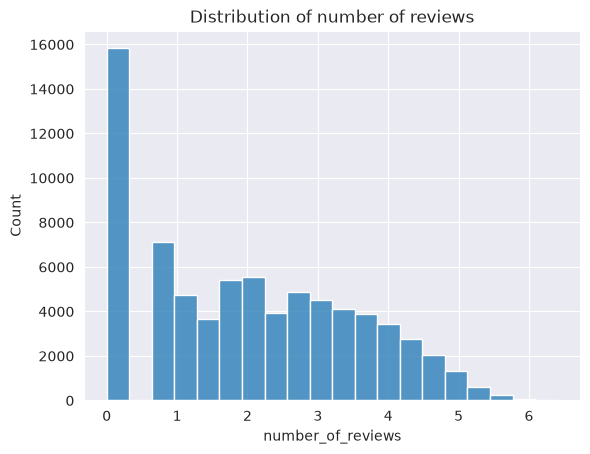

In [64]:
sns.histplot(
    x=np.log1p(df['number_of_reviews']),
    bins=20
)
plt.title("Distribution of number of reviews")
plt.show()

In [65]:
df['reviews_group'] = pd.qcut(
    df['number_of_reviews'],
    q=5,
    duplicates='drop'
)

df.groupby('reviews_group')['price'].agg([
    'median', 'mean', 'count'
])

,median,mean,count
reviews_group,,,
"(-0.001, 3.0]",115.0,179.247958,31336
"(3.0, 10.0]",110.0,150.096373,13759
"(10.0, 31.0]",115.0,150.191101,14249
"(31.0, 605.0]",110.0,139.708878,14767


In [66]:
df.groupby('reviews_group')['review_scores_rating'].median()

reviews_group
(-0.001, 3.0]    100.0
(3.0, 10.0]       96.0
(10.0, 31.0]      96.0
(31.0, 605.0]     95.0
Name: review_scores_rating, dtype: float64

In [67]:
df['review_scores_rating'].describe()

count    57389.000000
mean        94.067365
std          7.836556
min         20.000000
25%         92.000000
50%         96.000000
75%        100.000000
max        100.000000
Name: review_scores_rating, dtype: float64

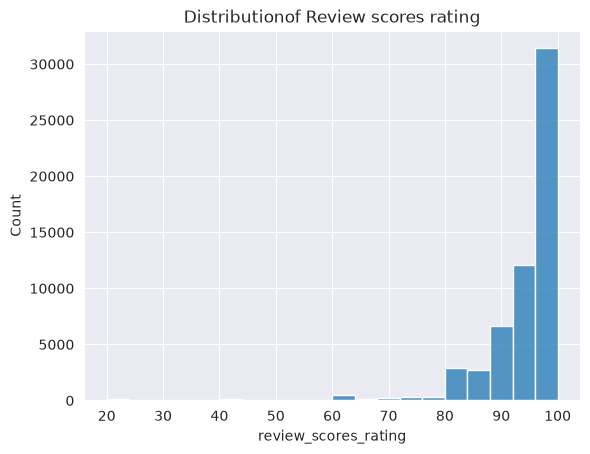

In [68]:
sns.histplot(
    df['review_scores_rating'],
    bins=20
)

plt.title("Distributionof Review scores rating")
plt.show()

In [69]:
df['review_scores_group'] = pd.cut(
    df['review_scores_rating'],
    bins=[0, 80, 90, 95, 98, 100]
)

df.groupby('review_scores_group')['price'].agg([
    'median', 'mean', 'count'
])

,median,mean,count
review_scores_group,,,
"(0, 80]",98.0,131.300361,3882
"(80, 90]",100.0,131.594540,8462
"(90, 95]",110.0,141.263894,13657
"(95, 98]",116.0,149.593207,12542
"(98, 100]",119.0,161.860713,18846


In [70]:
df.groupby('review_scores_group')['number_of_reviews'].median()

review_scores_group
(0, 80]       2.0
(80, 90]     13.0
(90, 95]     22.0
(95, 98]     25.0
(98, 100]     3.0
Name: number_of_reviews, dtype: float64

### Numerical Feature Analysis Conclusion

During the analysis of numerical features, several important relationships between numerical variables and the target variable (`price`) were identified.

The strongest relationships were observed among property-related features. Features describing the size and capacity of a listing showed a clear positive relationship with price:

* `accommodates` demonstrated a strong correlation with price. Listings with higher guest capacity generally had higher median prices, indicaating the larger proportion tend to be more expensive.
* `bedrooms` and `bathrooms` also showed a clear positive relationship with price. However, their effect on the type of accommodation. For example, listings with many bathrooms but classified as shared accommodation (such as dorms or hostels) do not necessarily represent expensive properties.
* Analysis of `beds` revealed several suspicious values, where `beds = 0`. After investigation, these cases aappeared inconsistent with other listing characteristics, as they had real beds according to `bed_type` and could accommodate guests. These values will be handled during preprocessing. A possible approach is to replace invalid zero values using information from related features, for example:
    * `if accommodates == 1`, set `beds = 1`;
    * otherwise estimate the minimum reasonable number of beds based on accommodation capacity.

----

Host-rrelated and review-related features showed weaker but still meaningful patterns:

* `host_response_rate` had a weak direct relationship with price. However it showed a strong connection with listing activity: hosts with higher response rates tended to have more reviews. This suggests that response rate may influence price indirectly through guest engagement and listing performance.
* `number_of_reviews` did not demonstrate a strong direct relationship with price. Instead it appears to represent listing activity and history rather than pricing power.
* `review_scores_rating` showed a moderate positive relationship with price. Higher-related listings generally had slighly higher prices, suggesting that guest satisfaction contributes to perceived value. However, rating values should be interpreted together with review volume, as listings with very few reviews can have artificially high scores.

----

Overal, numerical feature analysis showed that the main price drivers are structural ccharacteristics of the property, such as accommodation capacity, number of bedrooms and bathrooms. Review and host-related features appear to provide additional information, but their influence is weaker and often depends on interactions with other variables.

No additional engineered numerical features were created during this stage. The main preprocessing step identified for future implementation concerns handling inconsistent `beds` values.

## Longitude and Latitude Analysis

Unlike traditional numerical features, geographical coordinates contain spatial information that cannot be fully captured through standard statistical analysis.

The `latitude` and `longitude` features represent the physical location of each listings which may have a significant impact on the target variable (`price`).

Therefore, these features are analyzed separately to understand:

* how listings are geographicaly distributed;
* whether specific areas have different price patterns;
* whether spatial relationships can provide additional predictive power;

This section focuses not only on exploraatory analysis but also on possible feature extraction techuniques based on geographical information.

### Feature Extraction from Coordinates

Raw latitude and longitude values are often difficult for machine learning models to interpret directly.

Therefore, additional spatial features may be extracted such as:

* distance from a central reference point (`distance_from_center`);
* distance to important landmarks or city areas (if available);
* local density of listings;
* geographical clusters representing similar areas;

These features may help the model capture location-based pricing patterns more effectively.

### Spatial Clustering Experiments

Since listings located near each other often share similar characteristics, clustering algorithms can be applied to coordinate data.

Possible approaches:

* clustering listings based on `latitude` and `longitude`;
* creating categorical spatial groups;
* comparing cluster-based features with raw coordinates;

The goal is to determine whether automatically discovered geographical regions provide additional information beyond the original coordinate features.

### Comparison with Zipcode / Neighborhood Features

Geographical identifiers such as `zipcode` or `neighborhood` may contain similar information to coordinates.

Therefore, an additional experiment to compare:

* raw coordinates features;
* engineered spatial features;
* existing geographical categories;

This helps evaluate whether coordinate-based feature extrraction provides additional value or whether existing location-based features already capture most of the spatial information.

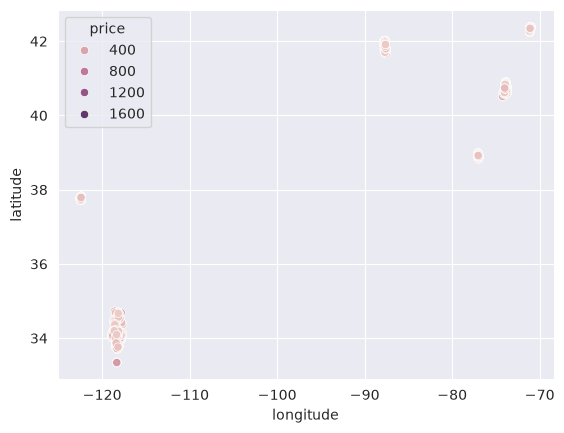

In [71]:
sns.scatterplot(
    data=df,
    x='longitude',
    y='latitude',
    hue='price'
)

plt.show()

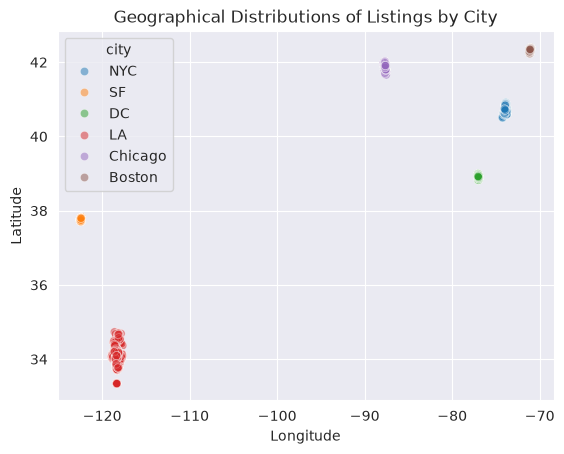

In [72]:
sns.scatterplot(
    data=df,
    x='longitude',
    y='latitude',
    hue='city',
    alpha=0.5
)

plt.title("Geographical Distributions of Listings by City")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.show()

In [73]:
df.groupby(
    pd.cut(df['longitude'], bins=10)
)['price'].agg(['count', 'median', 'mean'])

,count,median,mean
longitude,,,
"(-122.563, -117.359]",28887,116.0,171.421297
"(-91.596, -86.443]",3719,99.0,132.476472
"(-81.29, -76.138]",5688,125.0,217.933368
"(-76.138, -70.985]",35817,110.0,145.213502


In [74]:
df.groupby(
    pd.cut(df['latitude'], bins=10)
)['price'].agg(['count', 'median', 'mean'])

,count,median,mean
latitude,,,
"(33.33, 34.244]",22126,100.0,155.813839
"(34.244, 35.149]",327,69.0,126.590214
"(36.96, 37.865]",6434,165.0,227.372552
"(38.77, 39.675]",5688,125.0,217.933368
"(39.675, 40.58]",89,95.0,125.730337
"(40.58, 41.485]",32260,105.0,143.072288
"(41.485, 42.39]",7187,115.0,148.475024


In [75]:
df[['longitude', 'latitude']].describe()

,longitude,latitude
count,74111.000000,74111.000000
mean,-92.397525,38.445958
std,21.705322,3.080167
min,-122.511500,33.338905
25%,-118.342374,34.127908
50%,-76.996965,40.662138
75%,-73.954660,40.746096
max,-70.985047,42.390437


In [76]:
df['city'].unique()

<StringArray>
['NYC', 'SF', 'DC', 'LA', 'Chicago', 'Boston']
Length: 6, dtype: str

In [77]:
listing_centers = df.groupby('city')[['longitude', 'latitude']] \
    .median() \
    .rename(columns={
        "latitude": "listing_center_lat",
        "longitude": "listing_center_lon"
    })

listing_centers

,listing_center_lon,listing_center_lat
city,,
Boston,-71.077042,42.345295
Chicago,-87.662839,41.909945
DC,-77.022636,38.912063
LA,-118.349790,34.067141
NYC,-73.956834,40.723900
SF,-122.426735,37.768530


In [78]:
df = df.merge(listing_centers, on='city',  how='left')

df.head(2)

,id,log_price,property_type,room_type,amenities,accommodates,bathrooms,bed_type,cancellation_policy,cleaning_fee,city,description,first_review,host_has_profile_pic,host_identity_verified,host_response_rate,host_since,instant_bookable,last_review,latitude,longitude,name,neighbourhood,number_of_reviews,review_scores_rating,thumbnail_url,zipcode,bedrooms,beds,price,host_age_days,days_since_last_review,review_history_days,host_since_year,last_review_year,first_review_year,review_before_host,response_group,reviews_group,review_scores_group,listing_center_lon,listing_center_lat
0,6901257,5.010635,Apartment,Entire home/apt,"{""Wireless Internet"",""Air conditioning"",Kitche...",3,1.0,Real Bed,strict,True,NYC,"Beautiful, sunlit brownstone 1-bedroom in the ...",2016-06-18,t,t,NaN,2012-03-26,f,2016-07-18,40.696524,-73.991617,Beautiful brownstone 1-bedroom,Brooklyn Heights,2,100.0,https://a0.muscache.com/im/pictures/6d7cbbf7-c...,11201,1.0,1.0,150.0,2018.0,444.0,30.0,2012.0,2016.0,2016.0,0,NaN,"(-0.001, 3.0]","(98, 100]",-73.956834,40.7239
1,6304928,5.129899,Apartment,Entire home/apt,"{""Wireless Internet"",""Air conditioning"",Kitche...",7,1.0,Real Bed,strict,True,NYC,Enjoy travelling during your stay in Manhattan...,2017-08-05,t,f,100.0,2017-06-19,t,2017-09-23,40.766115,-73.989040,Superb 3BR Apt Located Near Times Square,Hell's Kitchen,6,93.0,https://a0.muscache.com/im/pictures/348a55fe-4...,10019,3.0,3.0,169.0,107.0,12.0,49.0,2017.0,2017.0,2017.0,0,"(95.0, 100.0]","(3.0, 10.0]","(90, 95]",-73.956834,40.7239


In [79]:
# Mean Earth radius in km
EARTH_RADIUS = 6371

lat1 = np.radians(df['latitude'])
lon1 = np.radians(df['longitude'])

lat2 = np.radians(df['listing_center_lat'])
lon2 = np.radians(df['listing_center_lon'])

def haversine(lat1, lat2, lon1, lon2):

    dlat = lat2 - lat1
    dlon = lon2 - lon1

    a = np.sin(dlat / 2)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon / 2)**2
    c = 2 * np.asin(np.sqrt(a))

    return EARTH_RADIUS * c

df['distance_to_listing_center'] = haversine(lat1, lat2, lon1, lon2)

df['distance_to_listing_center'].describe()

count    74111.000000
mean         7.748335
std          8.215147
min          0.001732
25%          3.055308
50%          4.992963
75%          9.357726
max         83.647147
Name: distance_to_listing_center, dtype: float64

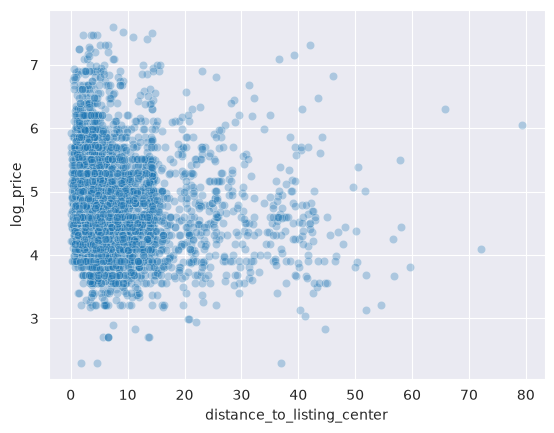

In [80]:
sns.scatterplot(
    data=df.sample(5000, random_state=42),
    x='distance_to_listing_center',
    y='log_price',
    alpha=0.3
)

plt.show()

In [81]:
df[['distance_to_listing_center', 'log_price']].corr(method='spearman')

,distance_to_listing_center,log_price
distance_to_listing_center,1.000000,-0.222216
log_price,-0.222216,1.000000


In [82]:
df.groupby(pd.qcut(df['distance_to_listing_center'], q=10))['price'].agg([
    'median', 'mean', 'count'
])

,median,mean,count
distance_to_listing_center,,,
"(0.00073, 1.65]",145.0,190.042364,7412
"(1.65, 2.627]",135.0,181.696532,7411
"(2.627, 3.446]",135.0,188.862097,7411
"(3.446, 4.164]",125.0,178.348401,7411
"(4.164, 4.993]",119.0,165.604507,7411
"(4.993, 6.171]",105.0,146.640399,7411
"(6.171, 8.194]",99.0,138.846579,7411
"(8.194, 10.987]",95.0,126.313048,7411
"(10.987, 15.457]",99.0,141.354068,7411


In [83]:
neighbourhood_stats = (
    df.groupby('neighbourhood')['price'].agg([
        'median', 'mean', 'count'
    ]).sort_values('median')
)

neighbourhood_stats.head(10)

,median,mean,count
neighbourhood,,,
Twining,19.5,182.300000,10
South Chicago,20.0,25.000000,6
West Elsdon,30.0,30.000000,3
Daly City,32.0,223.400000,5
Grasmere,33.0,53.750000,4
West Lawn,34.0,36.250000,4
Englewood,35.0,69.384615,13
"Suitland-Silver Hill, MD",37.0,37.000000,1
Belmont Cragin,39.0,60.818182,11


In [84]:
neighbourhood_stats[neighbourhood_stats['count'] > 100].sort_values('median')

,median,mean,count
neighbourhood,,,
Elmhurst,55.0,75.465116,129
Sunset Park,59.0,74.962025,158
Jackson Heights,60.0,83.517730,141
West Adams,60.0,85.015748,127
South LA,60.0,90.768000,250
...,...,...,...
Pacific Palisades,250.0,386.265625,128
Tribeca,250.0,360.233010,103
Bel Air/Beverly Crest,259.0,527.809160,131


In [85]:
df.groupby('zipcode')[['log_price', 'distance_to_listing_center']].corr()

log_price  \
zipcode                                                                                    
                                                   log_price                    1.000000   
                                                   distance_to_listing_center   1.000000   
02108                                              log_price                    1.000000   
                                                   distance_to_listing_center  -0.151106   
02109                                              log_price                    1.000000   
...                                                                                  ...   
95202\r\r\r\r\r\r\n\r\r\r\r\r\r\n\r\r\r\r\r\r\n... distance_to_listing_center        NaN   
99135                                              log_price                         NaN   
                                                   distance_to_listing_center        NaN   
Near 91304                                         log_price                         NaN   
                                                   distance_to_listing_center        NaN   

                                                                               distance_to_listing_center  
zipcode                                                                                                    
                                                   log_price                                     1.000000  
                                                   distance_to_listing_center                    1.000000  
02108                                              log_price                                    -0.151106  
                                                   distance_to_listing_center                    1.000000  
02109                                              log_price                                    -0.325622  
...                                                                                                   ...  
95202\r\r\r\r\r\r\n\r\r\r\r\r\r\n\r\r\r\r\r\r\n... distance_to_listing_center                         NaN  
99135                                              log_price                                          NaN  
                                                   distance_to_listing_center                         NaN  
Near 91304                                         log_price                                          NaN  
                                                   distance_to_listing_center                         NaN  

[1538 rows x 2 columns]

### Longitude and Latitude Analysis Conclusion

During the analysis of geographical features, the first step was to examine the spatial distribution of listings using **latitude** and **longitude** coordinates. The scatter plot revealed several clearly separatable spatial groups, which corresponded to the existing `city` feature. This indicates that the main geographical structure of the dataset is already captured by the city labels. Therefore, applying global clustering algorithms such as **KMeans** would likely reproduce the existing city groups rather than extract additional meaningful information.

To investigate whether raw coordinates contain additional predictive information, a new feature `distance_to_listing_center` was created. The feature was calculated using the **Haversine** distance formula, implemented through a custom vectorized function, to measure the distance between each listing and estimated center of its city (using *median* values).

The analysis showed that `distance_to_listing_center` has a moderate negative relationship with `log_price`, meaning that listings located farther from the central areas tend to have lower prices. At the same time, the feature demonstrated a relationship with existing location-based feature such as `neighbourhood`, suggesting that part of its information overlaps with existing geographical features. However, it does not fully duplicate them and may capture additional spatial variation.

The relationship between `distance_to_listing_center` and `zipcode` was also investigated. However, this analysis did not provide reliable conclusions due to the high number of irregular values, repeated categories and resulting missing correlation values. The large amount of `NaN` values made correlation analysis inconclusive. This suggests that `zipcode` and `distance_to_listing_center` likely represent different aspects of geographical information rather than being direct duplicates. 

Based on the findings, `distance_to_listing_center` will be retained as a potential feature for the modeling stage. Its final contribution will be evaluated through model performance comparisons and further feature importance analysis.

## Categorical Feature Analysis

In [87]:
cat_features = [
    'property_type',
    'room_type',
    'bed_type',
    'cancellation_policy',
    'cleaning_fee',
    'city',
    'host_has_profile_picture',
    'host_identity_verified',
    'instant_bookable',
    'name',
    'neighbourhood',
    'thumbnail_url',
    'zipcode'
]

In [89]:
df['property_type'].unique()

<StringArray>
[         'Apartment',              'House',        'Condominium',
               'Loft',          'Townhouse',             'Hostel',
        'Guest suite',    'Bed & Breakfast',           'Bungalow',
         'Guesthouse',               'Dorm',              'Other',
          'Camper/RV',              'Villa',     'Boutique hotel',
          'Timeshare',             'In-law',               'Boat',
 'Serviced apartment',             'Castle',              'Cabin',
          'Treehouse',               'Tipi',      'Vacation home',
               'Tent',                'Hut',    'Casa particular',
             'Chalet',               'Yurt',        'Earth House',
      'Parking Space',              'Train',               'Cave',
         'Lighthouse',             'Island']
Length: 35, dtype: str

In [90]:
df['property_type'].value_counts()

property_type
Apartment             49003
House                 16511
Condominium            2658
Townhouse              1692
Loft                   1244
Other                   607
Guesthouse              498
Bed & Breakfast         462
Bungalow                366
Villa                   179
Dorm                    142
Guest suite             123
Camper/RV                94
Timeshare                77
Cabin                    72
In-law                   71
Hostel                   70
Boutique hotel           69
Boat                     65
Serviced apartment       21
Tent                     18
Castle                   13
Vacation home            11
Yurt                      9
Hut                       8
Treehouse                 7
Chalet                    6
Earth House               4
Tipi                      3
Train                     2
Cave                      2
Casa particular           1
Parking Space             1
Lighthouse                1
Island                    1
Name: 

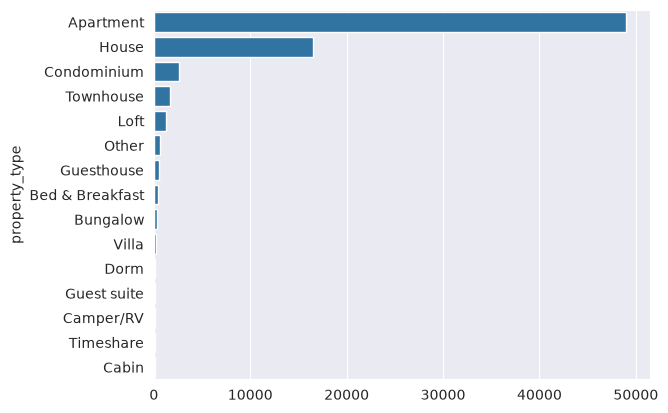

In [93]:
top = df['property_type'].value_counts().head(15)

sns.barplot(
    x=top.values,
    y=top.index
)

plt.show()

In [95]:
(df['property_type'].value_counts() < 10).sum()

np.int64(12)

In [107]:
top

property_type
Apartment          49003
House              16511
Condominium         2658
Townhouse           1692
Loft                1244
Other                607
Guesthouse           498
Bed & Breakfast      462
Bungalow             366
Villa                179
Dorm                 142
Guest suite          123
Camper/RV             94
Timeshare             77
Cabin                 72
Name: count, dtype: int64